# Tutorial: Graph ingestion visualization pipeline

This notebook shows the canonical graph-ingestion visualization flow:

1. preview the raw weighted graph,
2. inspect the preflight estimate,
3. inspect the normalized ingestion plan,
4. build a graded complex and inspect the resulting diagnostics.

The example is intentionally small so the graph preview, plan dashboard, and graded-complex dashboard all fit into one notebook session.


## Setup

This cell loads `TamerOp` from either the active environment or the local checkout, then activates any available visualization backend.

Later cells use fully qualified calls like `TO.visualize(...)` to avoid notebook-binding issues. For notebook reliability, inline rendering prefers `CairoMakie` when it is available.


In [1]:
global _TO_ROOT = let
    dir = abspath(pwd())
    root = nothing
    while true
        if isfile(joinpath(dir, "src", "TamerOp.jl"))
            root = dir
            break
        end
        parent = dirname(dir)
        parent == dir && error("Could not locate repo root containing src/TamerOp.jl from pwd()=$(pwd()).")
        dir = parent
    end
    root
end

if isdefined(Main, :TamerOp)
    global TO = Base.invokelatest(getfield, Main, :TamerOp)
else
    try
        @eval Main using TamerOp
        global TO = Base.invokelatest(getfield, Main, :TamerOp)
    catch
        Base.include(Main, joinpath(_TO_ROOT, "src", "TamerOp.jl"))
        global TO = Base.invokelatest(getfield, Main, :TamerOp)
    end
end

for pkg in (:WGLMakie, :CairoMakie)
    try
        Base.require(Main, pkg)
    catch
    end
end

for backend in (:wglmakie, :cairomakie)
    try
        Base.invokelatest(TO.Visualization._try_load_visual_backend!, backend)
    catch
    end
end

global TOA = TO.Advanced
global DI = TO.DataIngestion
global DT = TO.DataTypes
global CM = TO.CoreModules

global DISPLAY_VIS_BACKEND = if TO.Visualization._visual_backend_available(:cairomakie)
    :cairomakie
elseif TO.Visualization._visual_backend_available(:wglmakie)
    :wglmakie
else
    :auto
end

global EXPORT_VIS_BACKEND = if TO.Visualization._visual_backend_available(:cairomakie)
    :cairomakie
elseif TO.Visualization._visual_backend_available(:wglmakie)
    :wglmakie
else
    :auto
end

println("Visualization backends loaded: ", collect(keys(TO.Visualization._VISUAL_RENDERERS)))
println("Notebook display backend: ", DISPLAY_VIS_BACKEND)
println("Notebook export backend: ", EXPORT_VIS_BACKEND)


Visualization backends loaded: [:wglmakie, :cairomakie]
Notebook display backend: cairomakie
Notebook export backend: cairomakie


## 1. Build a weighted graph and inspect the available ingestion visuals


In [2]:
data = TO.GraphData(
    5,
    [(1, 2), (2, 3), (1, 3), (3, 4), (4, 5), (3, 5), (2, 4)];
    coords=[(-0.90, 0.10), (-0.20, 0.70), (0.35, 0.05), (1.00, 0.55), (1.55, -0.20)],
    weights=[0.40, 0.70, 0.50, 0.30, 0.80, 0.60, 0.90],
)

vertex_labels = ["v$(i)" for i in 1:DT.nvertices(data)]

TO.available_visuals(data)


(:graph, :weighted_graph)

In [3]:
weighted_spec = TOA.visual_spec(data; kind=:weighted_graph, labels=vertex_labels)
TOA.visual_summary(weighted_spec)


(kind = :visualization_spec, visual_kind = :weighted_graph, title = "Graph preview", subtitle = "weighted-edge view", nlayers = 5, npanels = 0, layer_types = (:SegmentLayer, :SegmentLayer, :SegmentLayer, :PointLayer, :TextLayer), axes = (xlabel = "x1", ylabel = "x2", xlimits = (-1.047, 1.697), ylimits = (-0.26, 0.76), zlabel = "z", zlimits = nothing, aspect = :equal, xticks = nothing, yticks = nothing), metadata = (object = :graph_data, projected_dims = (1, 2), layout = :embedded, nvertices = 5, nedges = 7), legend_visible = true, interaction = (hover = true, labels = true, clicks = false, widgets = (), notebook = :summary_card))

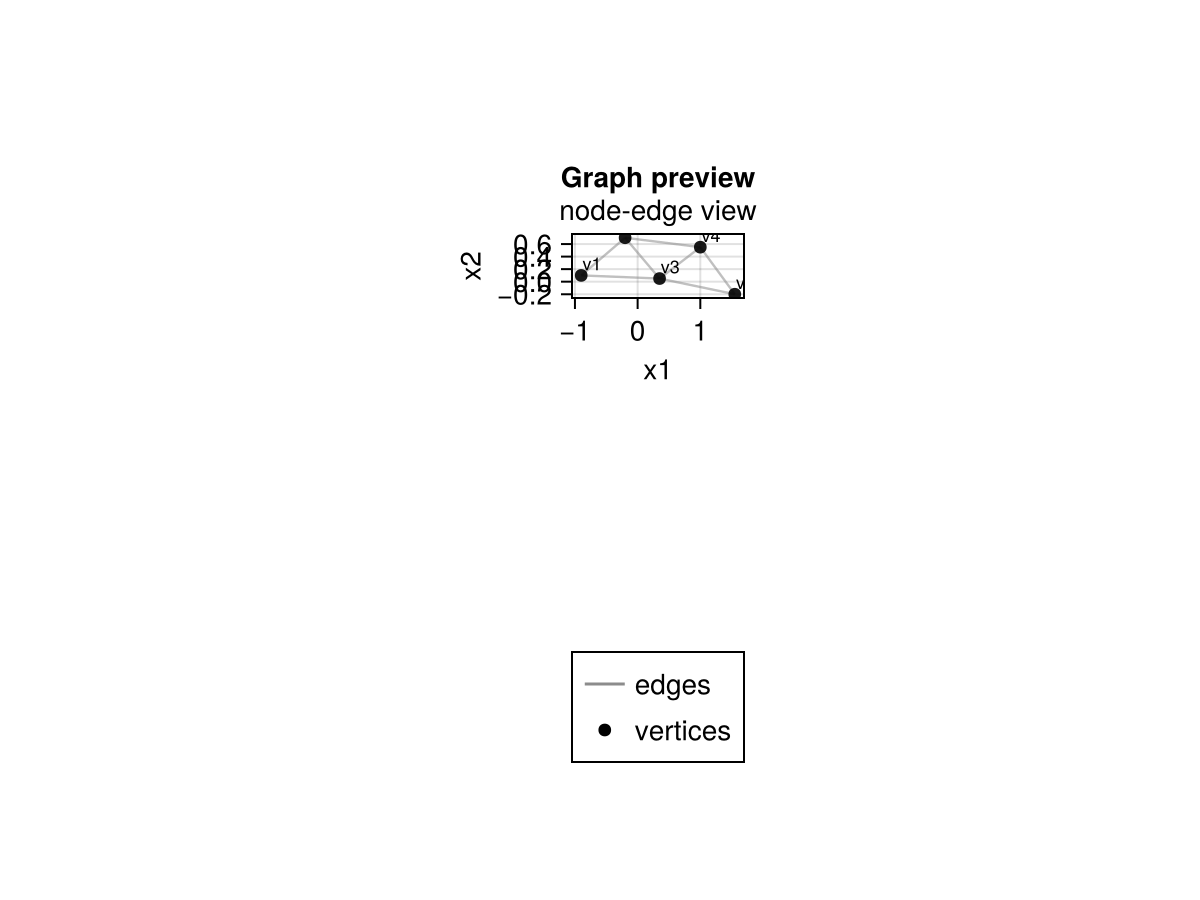

In [4]:
TO.visualize(data; kind=:graph, labels=vertex_labels, backend=DISPLAY_VIS_BACKEND)


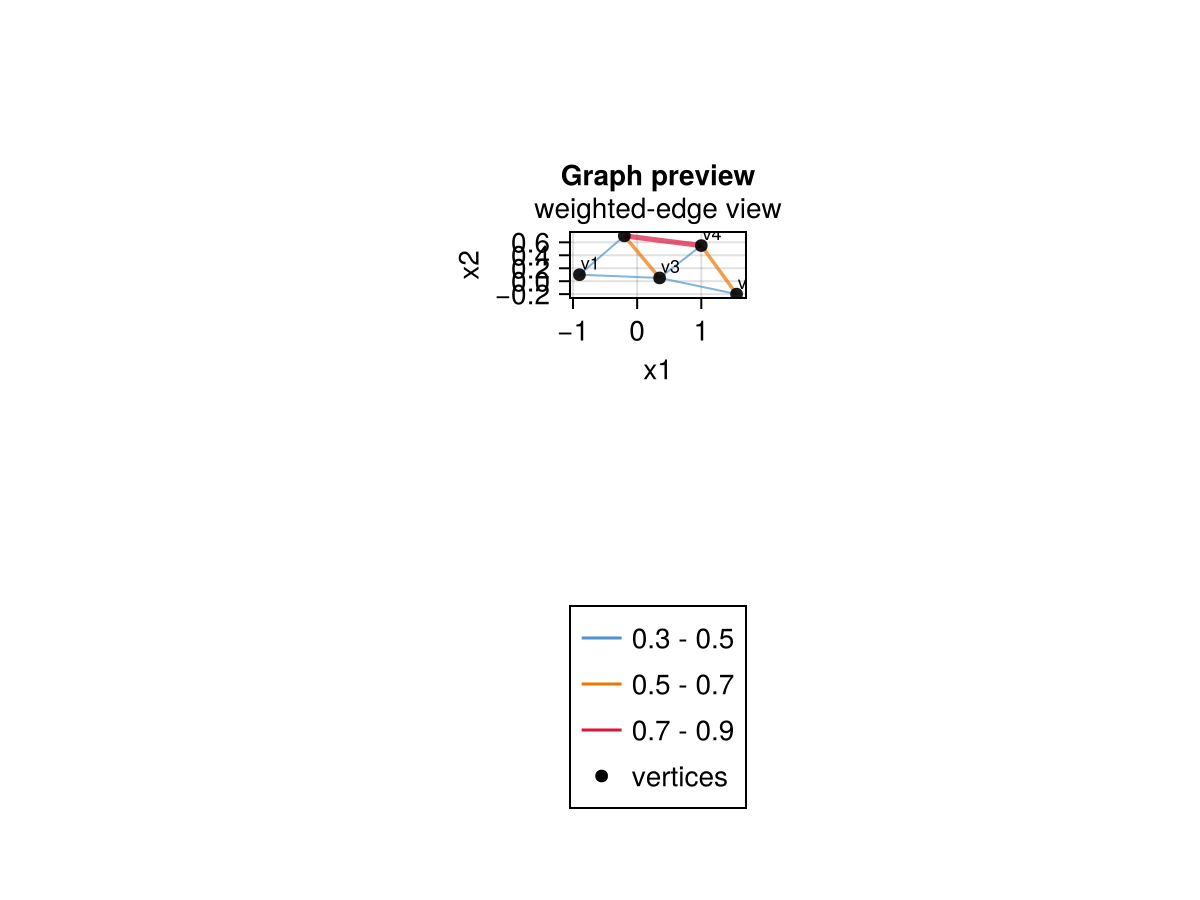

In [5]:
TO.visualize(data; kind=:weighted_graph, labels=vertex_labels, backend=DISPLAY_VIS_BACKEND)


## 2. Build a typed graph bifiltration, inspect the estimate, and render the preflight dashboard


In [6]:
construction = TO.ConstructionOptions(;
    sparsify=:none,
    collapse=:none,
    output_stage=:graded_complex,
    budget=(max_simplices=128, max_edges=32, memory_budget_bytes=2_000_000),
)

filtration = TO.GraphFunctionGeodesicBifiltration(;
    sources=[1],
    metric=:weighted,
    vertex_values=[0.15, 0.55, 0.30, 0.75, 0.45],
    lift=:clique,
    max_dim=2,
    simplex_agg=:max,
    construction=construction,
)

est = DI.estimate_ingestion(data, filtration)

(DI.filtration_summary(filtration), DI.ingestion_estimate_summary(est))


((kind = :graph_function_geodesic_bifiltration, filtration_type = :GraphFunctionGeodesicBifiltration, arity = 2, key_params = (sources = (type = :Array, length = 1), metric = :weighted, vertex_values = (type = :Array, length = 5), lift = :clique, max_dim = 2, simplex_agg = :max), construction_mode = (sparsify = :none, collapse = :none, output_stage = :graded_complex)), (kind = :ingestion_estimate, estimated_cells = 25, cell_counts_by_dim = BigInt[5, 10, 10], estimated_axis_sizes = nothing, estimated_poset_size = nothing, estimated_nnz = 50, estimated_dense_bytes = 800, nwarnings = 2))

In [7]:
est

(DI.ingestion_estimate_summary(est), DI.estimate_warnings(est))


((kind = :ingestion_estimate, estimated_cells = 25, cell_counts_by_dim = BigInt[5, 10, 10], estimated_axis_sizes = nothing, estimated_poset_size = nothing, estimated_nnz = 50, estimated_dense_bytes = 800, nwarnings = 2), ["Graph clique-based estimate is an upper bound (complete-graph assumption).", "axis_sizes unavailable without explicit axes for dataset type GraphData{Float64}."])

## 3. Build and inspect the normalized ingestion plan


In [8]:
plan = DI.plan_ingestion(
    data,
    filtration;
    field=CM.QQField(),
    cache=:auto,
    preflight=true,
)

(DI.ingestion_plan_summary(plan), DI.check_ingestion_plan(plan; throw=false))


((kind = :ingestion_plan, data_kind = :graph, filtration_kind = :graph_function_geodesic_bifiltration, planned_stage = :graded_complex, field = :QQField, route_hint = :simplex_tree_first, has_preflight = true, construction_mode = (sparsify = :none, collapse = :none, output_stage = :graded_complex), multicritical_mode = :union), (kind = :ingestion_plan, valid = true, data_kind = :graph, filtration_kind = :graph_function_geodesic_bifiltration, planned_stage = :graded_complex, field = :QQField, route_hint = :simplex_tree_first, has_preflight = true, issues = String[]))

In [9]:
TO.available_visuals(plan)


()

In [10]:
plan

(DI.ingestion_plan_summary(plan), DI.check_ingestion_plan(plan; throw=false))


((kind = :ingestion_plan, data_kind = :graph, filtration_kind = :graph_function_geodesic_bifiltration, planned_stage = :graded_complex, field = :QQField, route_hint = :simplex_tree_first, has_preflight = true, construction_mode = (sparsify = :none, collapse = :none, output_stage = :graded_complex), multicritical_mode = :union), (kind = :ingestion_plan, valid = true, data_kind = :graph, filtration_kind = :graph_function_geodesic_bifiltration, planned_stage = :graded_complex, field = :QQField, route_hint = :simplex_tree_first, has_preflight = true, issues = String[]))

## 4. Run the canonical workflow to the graded-complex stage

The notebook inspected `estimate_ingestion(...)` and `plan_ingestion(...)` explicitly. For the actual stage computation, use the canonical public workflow entrypoint `encode(...; stage=:graded_complex)`, not the owner-level builder.


In [11]:
graded_complex = TO.encode(
    data,
    filtration;
    stage=:graded_complex,
    field=CM.QQField(),
    cache=:auto,
)

(DT.data_summary(graded_complex), DT.check_graded_complex(graded_complex; throw=false))


((kind = :graded_complex, max_dim = 2, cell_counts = [5, 7, 3], parameter_dim = 2, ncells = 15), (kind = :graded_complex, valid = true, max_dim = 2, cell_counts = [5, 7, 3], parameter_dim = 2, issues = String[]))

In [12]:
TO.available_visuals(graded_complex)


()

In [13]:
graded_complex

(DT.data_summary(graded_complex), DT.check_graded_complex(graded_complex; throw=false))


((kind = :graded_complex, max_dim = 2, cell_counts = [5, 7, 3], parameter_dim = 2, ncells = 15), (kind = :graded_complex, valid = true, max_dim = 2, cell_counts = [5, 7, 3], parameter_dim = 2, issues = String[]))

## 5. Save the actual graph visuals to disk

This notebook keeps ingestion, plan, and graded-complex-stage diagnostics as pretty-printed summaries. Only the graph previews are exported, and the canonical batch helper `save_visuals(...)` chooses PNG vs HTML automatically.


In [14]:
outdir = joinpath(_TO_ROOT, "examples", "_outputs", "12_graph_ingestion_visualization_pipeline")

exports = TO.save_visuals(outdir,
                          [
                              (; stem="graph_preview", obj=data, kind=:graph),
                              (; stem="graph_weighted_preview", obj=data, kind=:weighted_graph),
                          ];
                          prefer=:static)

Dict(TO.export_stem(r) => TO.export_path(r) for r in exports)


Dict{String, String} with 2 entries:
  "graph_preview"          => "/home/eriknovak/Documents/duke_fall_2025/tamer-o…
  "graph_weighted_preview" => "/home/eriknovak/Documents/duke_fall_2025/tamer-o…

## Notes

- This notebook keeps graph-ingestion, plan, and graded-complex-stage diagnostics as pretty-printed summaries rather than Makie figures.
- `estimate_ingestion(...)` and `plan_ingestion(...)` are inspected explicitly, but the actual stage computation uses the canonical public workflow entrypoint `encode(...; stage=:graded_complex)`.
- `describe(...)`, `ingestion_estimate_summary(...)`, `ingestion_plan_summary(...)`, `data_summary(...)`, and `check_graded_complex(...)` are the canonical cheap-first diagnostics for these objects.
- The exported artifacts are the actual graph visuals only.
